# Support enumeration for Nash equilibria

Companion notebook to Supplementary Reading S1, *Centralized algorithms for Nash equilibrium computation*, Section "Support Enumeration Algorithms".

Support enumeration guesses the **support** of each player's equilibrium strategy (the actions played with positive probability) and then solves the equilibrium conditions restricted to that guess.

* **Two players.** For a fixed guess, the conditions form a **linear program**, so each guess costs one LP and there are at most $2^{m+n}$ guesses (Part 1).
* **$n \ge 3$ players.** For a fixed guess, the conditions form a **system of polynomial equations and inequalities** of degree $n-1$. This is *not* a linear program in general. Its solutions can be irrational, which no LP with rational data can produce (Part 2).

The code is a template: short, readable, and meant for small games. Python indexes actions from 0, but printouts use 1-based action labels, matching the notes.

**Requirements:** `numpy`, `scipy`, `sympy`, `matplotlib`.

In [1]:
import itertools
import warnings
from fractions import Fraction

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from scipy.optimize import linprog


def nonempty_subsets(k):
    # All nonempty subsets of {0, ..., k-1}, smallest first.
    for size in range(1, k + 1):
        yield from itertools.combinations(range(k), size)


def show(support):
    # 1-based set notation, e.g. (1, 2) -> "{2,3}".
    return "{" + ",".join(str(a + 1) for a in support) + "}"


def as_fractions(v, max_denominator=1000):
    # Display helper: floats close to simple fractions.
    return "(" + ", ".join(str(Fraction(float(t)).limit_denominator(max_denominator)) for t in v) + ")"

## Part 1: Two-player games (one LP per guess)

Let $(R, C)$ be an $m \times n$ game. Given candidate supports $S_R \subseteq [m]$ and $S_C \subseteq [n]$, the notes solve the feasibility LP

$$
\begin{aligned}
e_i^\top R y &\ge e_k^\top R y && \forall i \in S_R,\ \forall k \in [m] && \text{(every } i \in S_R \text{ is a best response to } y)\\
x^\top C e_j &\ge x^\top C e_k && \forall j \in S_C,\ \forall k \in [n] && \text{(every } j \in S_C \text{ is a best response to } x)\\
\textstyle\sum_i x_i = 1,\ \sum_j y_j &= 1, \quad x, y \ge 0, && x_i = 0\ \forall i \notin S_R,\ y_j = 0\ \forall j \notin S_C.
\end{aligned}
$$

Row's constraints involve only $y$, and Column's only $x$, so every constraint is **linear**. Any feasible point is a Nash equilibrium, and a Nash equilibrium with supports $(S_R, S_C)$ is feasible. The objective is irrelevant, so we pass `c = 0` to `linprog`.

In [2]:
def support_lp(R, C, S_R, S_C):
    # Solve the feasibility LP for the guess (S_R, S_C).
    # Returns (x, y) if feasible, otherwise None.
    R, C = np.asarray(R, dtype=float), np.asarray(C, dtype=float)
    m, n = R.shape
    A_ub = []
    # Row: (e_k - e_i)^T R y <= 0.  Variables are stacked as (x, y).
    for i in S_R:
        for k in range(m):
            A_ub.append(np.concatenate([np.zeros(m), R[k] - R[i]]))
    # Column: x^T C (e_k - e_j) <= 0.
    for j in S_C:
        for k in range(n):
            A_ub.append(np.concatenate([C[:, k] - C[:, j], np.zeros(n)]))
    A_eq = [np.concatenate([np.ones(m), np.zeros(n)]),
            np.concatenate([np.zeros(m), np.ones(n)])]
    bounds = ([(0, None) if i in S_R else (0, 0) for i in range(m)]
              + [(0, None) if j in S_C else (0, 0) for j in range(n)])
    res = linprog(np.zeros(m + n), A_ub=A_ub, b_ub=np.zeros(len(A_ub)),
                  A_eq=A_eq, b_eq=[1, 1], bounds=bounds, method="highs")
    if res.status != 0:  # 2 means infeasible
        return None
    return res.x[:m], res.x[m:]


def is_nash(R, C, x, y, tol=1e-9):
    # No player gains more than tol by deviating to a pure action.
    R, C = np.asarray(R, dtype=float), np.asarray(C, dtype=float)
    return (R @ y).max() <= x @ R @ y + tol and (x @ C).max() <= x @ C @ y + tol


def support_enumeration(R, C):
    # Try every pair of supports. Yields (S_R, S_C, x, y) for each feasible guess.
    m, n = np.shape(R)
    for S_R in nonempty_subsets(m):
        for S_C in nonempty_subsets(n):
            solution = support_lp(R, C, S_R, S_C)
            if solution is not None:
                x, y = solution
                assert is_nash(R, C, x, y)
                yield S_R, S_C, x, y

### Example: a $3 \times 2$ game

This is the example game from the notes, due to von Stengel (2007).

In [3]:
R = np.array([[3, 3],
              [2, 5],
              [0, 6]])
C = np.array([[3, 2],
              [2, 6],
              [3, 1]])

for S_R, S_C in [((1, 2), (0, 1)),   # guess S_R = {2,3}, S_C = {1,2}
                 ((0, 2), (0, 1))]:  # guess S_R = {1,3}, S_C = {1,2}
    solution = support_lp(R, C, S_R, S_C)
    if solution is None:
        print(f"S_R = {show(S_R)}, S_C = {show(S_C)}: infeasible")
    else:
        x, y = solution
        print(f"S_R = {show(S_R)}, S_C = {show(S_C)}: x = {as_fractions(x)}, y = {as_fractions(y)}")

S_R = {2,3}, S_C = {1,2}: x = (0, 1/3, 2/3), y = (1/3, 2/3)
S_R = {1,3}, S_C = {1,2}: infeasible


Why is the second guess infeasible? Row's actions 1 and 3 tie only at $y_2 = 1/2$, but there action 2 earns more. The constraints over **all** $k \in [m]$, not just $k \in S_R$, rule this guess out. The plot shows Row's payoff from each action against Column's probability $y_2$ of action 2. The kinks of the upper envelope are the only places where Row can mix.

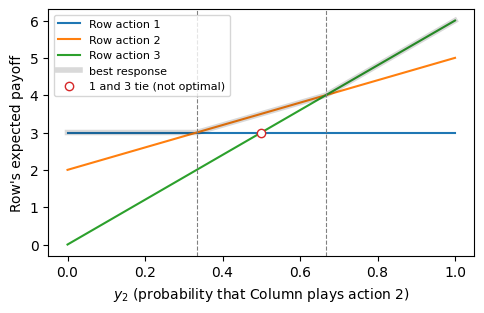

In [4]:
t = np.linspace(0, 1, 201)
payoffs = R[:, 0][:, None] * (1 - t) + R[:, 1][:, None] * t  # e_i^T R y for y = (1-t, t)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
for i, row in enumerate(payoffs):
    ax.plot(t, row, label=f"Row action {i + 1}")
ax.plot(t, payoffs.max(axis=0), color="black", lw=4, alpha=0.15, label="best response")
ax.plot([1 / 2], [3], "o", mfc="white", color="tab:red", label="1 and 3 tie (not optimal)")
for kink in (1 / 3, 2 / 3):
    ax.axvline(kink, color="gray", ls="--", lw=0.8)
ax.set_xlabel("$y_2$ (probability that Column plays action 2)")
ax.set_ylabel("Row's expected payoff")
ax.legend(fontsize=8)
plt.show()

Now enumerate all $(2^3-1)(2^2-1) = 21$ guesses.

In [5]:
m, n = R.shape
print(f"{'S_R':8} {'S_C':8} result")
for S_R in nonempty_subsets(m):
    for S_C in nonempty_subsets(n):
        solution = support_lp(R, C, S_R, S_C)
        result = "infeasible" if solution is None else f"x = {as_fractions(solution[0])}, y = {as_fractions(solution[1])}"
        print(f"{show(S_R):8} {show(S_C):8} {result}")

S_R      S_C      result
{1}      {1}      x = (1, 0, 0), y = (1, 0)
{1}      {2}      infeasible
{1}      {1,2}    infeasible
{2}      {1}      infeasible
{2}      {2}      infeasible
{2}      {1,2}    infeasible
{3}      {1}      infeasible
{3}      {2}      infeasible
{3}      {1,2}    infeasible
{1,2}    {1}      infeasible
{1,2}    {2}      infeasible
{1,2}    {1,2}    x = (4/5, 1/5, 0), y = (2/3, 1/3)
{1,3}    {1}      infeasible
{1,3}    {2}      infeasible
{1,3}    {1,2}    infeasible
{2,3}    {1}      infeasible
{2,3}    {2}      infeasible
{2,3}    {1,2}    x = (0, 1/3, 2/3), y = (1/3, 2/3)
{1,2,3}  {1}      infeasible
{1,2,3}  {2}      infeasible
{1,2,3}  {1,2}    infeasible


Exactly three guesses are feasible, and they give the three Nash equilibria of the game. All of them are rational, as the corollary in the notes guarantees: each is a vertex of a polytope with rational data.

A feasible LP certifies an equilibrium whose support is *contained in* the guess, so in general a solution can use fewer actions than guessed. To stop at the first equilibrium, take `next(support_enumeration(R, C))`.

### Try it yourself

Replace the matrices below with any game. Random games sampled from a continuous distribution are nondegenerate with probability one, so their equilibria are isolated.

In [6]:
rng = np.random.default_rng(0)
R_rand = rng.integers(0, 10, size=(4, 4))
C_rand = rng.integers(0, 10, size=(4, 4))

S_R, S_C, x, y = next(support_enumeration(R_rand, C_rand))
print("first equilibrium found:", f"S_R = {show(S_R)}, S_C = {show(S_C)}")
print("  x =", as_fractions(x), " y =", as_fractions(y))

found = {tuple(np.round(np.concatenate([x, y]), 9)) for _, _, x, y in support_enumeration(R_rand, C_rand)}
print("distinct equilibria found:", len(found))

first equilibrium found: S_R = {3}, S_C = {2}
  x = (0, 0, 1, 0)  y = (0, 1, 0, 0)
distinct equilibria found: 7


## Part 2: $n$-player games (a polynomial system, not an LP)

With supports $S_i \subseteq A_i$ guessed for every player $i$, a Nash equilibrium $x = (x_1, \dots, x_n)$ solves

$$
\begin{aligned}
u_i(a_i; x_{-i}) &\ge u_i(a_i'; x_{-i}) && \forall i,\ \forall a_i \in S_i,\ \forall a_i' \in A_i,\\
\textstyle\sum_{a_i} x_{i,a_i} &= 1,\quad x_{i,a_i} \ge 0 \ \ \forall a_i \in S_i, && x_{i,a_i} = 0 \ \ \forall a_i \notin S_i,
\end{aligned}
\qquad\text{where}\qquad
u_i(a_i; x_{-i}) = \sum_{a_{-i}} u_i(a_i, a_{-i}) \prod_{j \ne i} x_{j, a_j}.
$$

Each term of $u_i(a_i; x_{-i})$ is a product of $n-1$ variables, so the constraints are **polynomial of degree $n-1$**. With $n = 2$ this is the LP above. For $n \ge 3$ it is a genuine polynomial system. In general, such systems are solved with tools from the existential theory of the reals.

For tiny games we can let SymPy do it. For each player, we write the constraints as follows (with $a_i^0$ the first action in $S_i$):

* **equations:** $u_i(a_i; x_{-i}) = u_i(a_i^0; x_{-i})$ for $a_i \in S_i$ (indifference within the support), and $\sum_{a_i \in S_i} x_{i,a_i} = 1$;
* **inequalities:** $u_i(a_i^0; x_{-i}) \ge u_i(a_i'; x_{-i})$ for $a_i' \notin S_i$, and $x_{i,a_i} \ge 0$.

We solve the equations exactly with `sympy.solve`, keep the real solutions, and then check the inequalities.

In [7]:
def action_payoff(u, i, a_i, x):
    # u_i(a_i; x_{-i}) as a SymPy polynomial. u has shape (k_1, ..., k_n) and x[j][a] is a probability.
    ranges = [[a_i] if j == i else range(len(x[j])) for j in range(u.ndim)]
    return sp.expand(sum(
        sp.Rational(int(u[profile])) * sp.Mul(*[x[j][profile[j]] for j in range(u.ndim) if j != i])
        for profile in itertools.product(*ranges)
    ))


def support_system(game, supports):
    # The polynomial system for one guess. game[i] is player i's integer payoff array.
    # Returns (variables, equations == 0, inequalities >= 0, x).
    sizes = game[0].shape
    x = [[sp.Symbol(f"x{i + 1}_{a + 1}") if a in supports[i] else sp.Integer(0) for a in range(k)]
         for i, k in enumerate(sizes)]
    variables = [v for x_i in x for v in x_i if isinstance(v, sp.Symbol)]
    equations, inequalities = [], []
    for i, S_i in enumerate(supports):
        pay = [action_payoff(game[i], i, a, x) for a in range(sizes[i])]
        equations += [pay[a] - pay[S_i[0]] for a in S_i[1:]]
        equations.append(sum(x[i]) - 1)
        inequalities += [pay[S_i[0]] - pay[a] for a in range(sizes[i]) if a not in S_i]
        inequalities += [x[i][a] for a in S_i]
    return variables, equations, inequalities, x


def solve_support_system(game, supports, tol=1e-12):
    # All real solutions of the system for this guess that satisfy its inequalities.
    variables, equations, inequalities, x = support_system(game, supports)
    equilibria = []
    for solution in sp.solve(equations, variables, dict=True):
        if set(solution) != set(variables):
            warnings.warn(f"supports {[show(S) for S in supports]}: infinitely many solutions "
                          "(degenerate game); skipped in this template")
            continue
        if any(abs(complex(sp.N(value)).imag) > tol for value in solution.values()):
            continue
        if all(float(sp.N(g.subs(solution))) >= -tol for g in inequalities):
            equilibria.append([[sp.simplify(sp.sympify(v).subs(solution)) for v in x_i] for x_i in x])
    return equilibria


def support_enumeration_nplayer(game):
    # Try every profile of supports. Yields (supports, exact equilibrium).
    for supports in itertools.product(*[list(nonempty_subsets(k)) for k in game[0].shape]):
        for equilibrium in solve_support_system(game, supports):
            yield supports, equilibrium

### Sanity check: with two players the system is linear

Feeding the $3 \times 2$ game from Part 1 into the general code gives equations of degree 1. These are the LP's indifference constraints.

In [8]:
variables, equations, _, _ = support_system([R, C], [(1, 2), (0, 1)])
for eq in equations:
    print(f"degree {sp.Poly(eq, *variables).total_degree()}:  {eq} = 0")
print(solve_support_system([R, C], [(1, 2), (0, 1)]))

degree 1:  -2*x2_1 + x2_2 = 0
degree 1:  x1_2 + x1_3 - 1 = 0
degree 1:  4*x1_2 - 2*x1_3 = 0
degree 1:  x2_1 + x2_2 - 1 = 0
[[[0, 1/3, 2/3], [1/3, 2/3]]]


### Example: a three-player game with an irrational equilibrium

This is the game from the notes. Each player has two actions, and `payoffs[(a1, a2, a3)] = (u1, u2, u3)` uses 1-based actions.

In [9]:
payoffs = {
    (1, 1, 1): (1, -2, -1), (1, 2, 1): (3, 0, 3), (2, 1, 1): (0, 1, -3), (2, 2, 1): (0, 0, -3),
    (1, 1, 2): (-3, 1, 0),  (1, 2, 2): (-3, 0, 0), (2, 1, 2): (0, 3, 0), (2, 2, 2): (0, 0, 0),
}
game3 = [np.zeros((2, 2, 2), dtype=int) for _ in range(3)]
for profile, utilities in payoffs.items():
    for i in range(3):
        game3[i][tuple(a - 1 for a in profile)] = utilities[i]

Guess full supports for all three players. The indifference equations contain products such as `x2_1*x3_1`: each has degree $n - 1 = 2$.

In [10]:
full = [(0, 1)] * 3
variables, equations, inequalities, _ = support_system(game3, full)
for eq in equations:
    print(f"degree {sp.Poly(eq, *variables).total_degree()}:  {eq} = 0")

degree 2:  -x2_1*x3_1 + 3*x2_1*x3_2 - 3*x2_2*x3_1 + 3*x2_2*x3_2 = 0
degree 1:  x1_1 + x1_2 - 1 = 0
degree 2:  2*x1_1*x3_1 - x1_1*x3_2 - x1_2*x3_1 - 3*x1_2*x3_2 = 0
degree 1:  x2_1 + x2_2 - 1 = 0
degree 2:  x1_1*x2_1 - 3*x1_1*x2_2 + 3*x1_2*x2_1 + 3*x1_2*x2_2 = 0
degree 1:  x3_1 + x3_2 - 1 = 0


In [11]:
for x in solve_support_system(game3, full):
    for i, x_i in enumerate(x):
        print(f"x_{i + 1} = {x_i}  ~  {[round(float(v), 4) for v in x_i]}")

x_1 = [sqrt(2)/2, 1 - sqrt(2)/2]  ~  [0.7071, 0.2929]
x_2 = [3/2 - 3*sqrt(2)/4, -1/2 + 3*sqrt(2)/4]  ~  [0.4393, 0.5607]
x_3 = [2 - sqrt(2), -1 + sqrt(2)]  ~  [0.5858, 0.4142]


The unique solution involves $\sqrt{2}$: $x_{1,1} = 1/\sqrt{2}$, $x_{2,1} = (6 - 3\sqrt{2})/4$, $x_{3,1} = 2 - \sqrt{2}$. A feasible LP with rational coefficients always has a rational solution, so no LP built from these payoffs could have returned this equilibrium. The square roots come from the products of variables.

Finally, enumerate all $3^3 = 27$ support profiles and verify each equilibrium numerically.

In [12]:
def action_payoffs_numeric(u, i, x):
    # Vector of u_i(a_i; x_{-i}) over a_i, by contracting the other players' axes.
    t = u.astype(float)
    for j in reversed(range(u.ndim)):
        if j != i:
            t = np.tensordot(t, x[j], axes=([j], [0]))
    return t


def is_nash_nplayer(game, x, tol=1e-9):
    return all(action_payoffs_numeric(u, i, x).max() <= action_payoffs_numeric(u, i, x) @ x[i] + tol
               for i, u in enumerate(game))


for supports, x in support_enumeration_nplayer(game3):
    x_float = [np.array([float(v) for v in x_i]) for x_i in x]
    print(f"supports {[show(S) for S in supports]}: x = {x}")
    print(f"  verified Nash equilibrium: {is_nash_nplayer(game3, x_float)}")

supports ['{1}', '{2}', '{1}']: x = [[1, 0], [0, 1], [1, 0]]
  verified Nash equilibrium: True
supports ['{2}', '{1}', '{2}']: x = [[0, 1], [1, 0], [0, 1]]
  verified Nash equilibrium: True


supports ['{1,2}', '{1,2}', '{1,2}']: x = [[sqrt(2)/2, 1 - sqrt(2)/2], [3/2 - 3*sqrt(2)/4, -1/2 + 3*sqrt(2)/4], [2 - sqrt(2), -1 + sqrt(2)]]
  verified Nash equilibrium: True


The game has three equilibria: the pure profiles $(1, 2, 1)$ and $(2, 1, 2)$, and the irrational fully mixed one.

**Limitations of this template.**
* `sympy.solve` relies on Gröbner bases and scales badly. In general, the cost of solving each polynomial system is exponential in the number of variables, and there are up to $2^{nk}$ supports to try (see the running-time analysis in the notes).
* In degenerate games, a guess can have a continuum of solutions. The template warns and skips such guesses rather than describing the solution set.